# <p style="text-align: center;">Decrees EDA</p>

## Import libraries

In [73]:
import pandas as pd
import numpy as np

import glob
import os

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#import datetime as dt

## Set parameters

In [74]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
processed_data_folder_name = './../../data/processed'
decrees_filename = 'decrees.parquet'
decrees_filename_clean = 'decrees_clean.parquet'

## Import Decrees

In [75]:


df = pd.read_parquet(os.path.join(processed_data_folder_name, decrees_filename))

In [76]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision
43661,5063,LA GRAVE,2001-03-19,2001-03-25,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue
43662,5128,SAINT ANDRE D EMBRUN,2001-03-29,2001-03-29,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue
43663,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue
43664,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0100649A,Reconnue
43665,6057,L'ESCARENE,2000-10-30,2000-10-31,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue


## Data Recording Period 

In [77]:
df.describe()

,debut_evenement,fin_evenement,date_arrete,date_parution_jo
count,235462,235462,235462,235462
mean,2005-10-13 08:16:52.627090560,2006-01-17 04:56:49.711970304,2006-07-06 06:26:51.775997952,2006-07-18 04:28:52.804444160
min,1985-01-01 00:00:00,1985-05-15 00:00:00,1987-05-20 00:00:00,1987-05-24 00:00:00
25%,1999-12-25 00:00:00,1999-12-29 00:00:00,1999-12-29 00:00:00,1999-12-30 00:00:00
50%,2002-11-23 00:00:00,2002-12-31 00:00:00,2003-10-03 00:00:00,2003-10-19 00:00:00
75%,2016-01-01 00:00:00,2016-03-31 00:00:00,2016-09-16 00:00:00,2016-10-20 00:00:00
max,2024-05-24 00:00:00,2024-05-26 00:00:00,2024-06-18 00:00:00,2024-07-02 00:00:00


### Note

Gathered data are from 1982 to 2024.

## Describe Categorical Data

In [78]:
df.dtypes

insee                       object
nom_commune                 object
debut_evenement     datetime64[ns]
fin_evenement       datetime64[ns]
date_arrete         datetime64[ns]
date_parution_jo    datetime64[ns]
nom_peril                   object
code_peril                  object
franchise                   object
code_nor                    object
decision                    object
dtype: object

In [79]:
df.select_dtypes(include=['object']).describe()

,insee,nom_commune,nom_peril,code_peril,franchise,code_nor,decision
count,235462,235462,235462,235462,235462,235462,235462
unique,37496,33569,22,22,5,738,3
top,81065,SAINTE MARIE,Inondations et/ou Coulées de Boue,ICB,Simple,INTE9900627A,Reconnue
freq,55,101,112288,112288,189348,58229,130517


## Create year of event column

In [80]:
df['event_year'] = df['debut_evenement'].dt.year

In [81]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision,event_year
43661,5063,LA GRAVE,2001-03-19,2001-03-25,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2001
43662,5128,SAINT ANDRE D EMBRUN,2001-03-29,2001-03-29,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2001
43663,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2000
43664,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0100649A,Reconnue,2000
43665,6057,L'ESCARENE,2000-10-30,2000-10-31,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2000


In [82]:
df['decision'].value_counts()

decision
Reconnue                                   130517
Reconnue(sans impact sur la modulation)     65206
Non reconnue                                39739
Name: count, dtype: int64

## Decisions evolution

In [83]:
# Group by year and item, summing up sales
yearly_decisions = df.groupby(['event_year', 'decision']).size().reset_index(name='Count')
yearly_decisions.head()

,event_year,decision,Count
0,1985,Reconnue,4
1,1986,Reconnue,6
2,1987,Reconnue,4033
3,1988,Reconnue,3056
4,1989,Non reconnue,1


In [84]:
# Plotting with Plotly
fig = px.line(yearly_decisions, x='event_year', y='Count', color='decision', markers=True, title='Decisions evolution')
fig.update_layout(xaxis_title='event_year', yaxis_title='decisions count', legend_title='decisions type')
fig.add_vline(x=1999, line_width=1, line_dash="dash", line_color="black")
fig.add_vline(x=2003, line_width=1, line_dash="dash", line_color="black")
fig.add_vline(x=2022, line_width=1, line_dash="dash", line_color="black")
fig.add_vrect(x0=2003, x1=2022, line_width=0, fillcolor="yellow", opacity=0.15)
fig.show()

### Note

In 2003, the decision “Non reconnue” saw a significant increase in natural disaster cases. We should investigate whether this is due to a policy change or the involvement of a third party (e.g., municipalities) in requesting recognition. To ensure the relevance of our graphs, we should limit the data to two years before the maximum date, accounting for delays in granting recognition. The peak in 1999 for “Reconnue (sans impact sur la modulation)” likely corresponds to the storm that year. This decision category appears to have started in 1999 and does not occur annually.

## Keep only decrees with a recognition state.

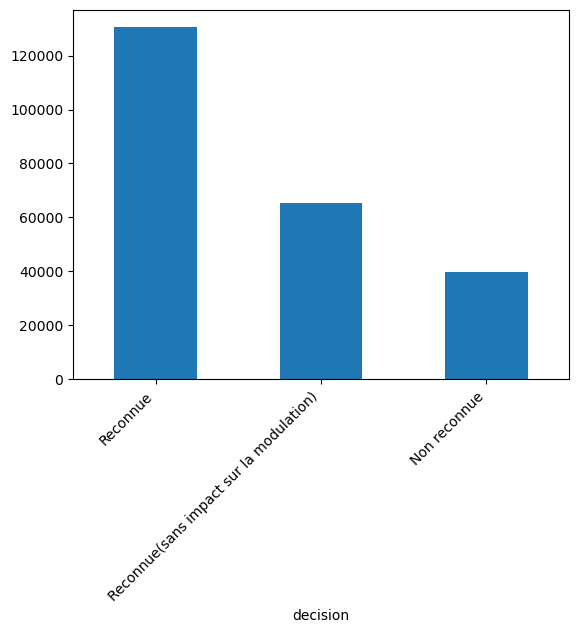

In [85]:
ax=df['decision'].value_counts().plot(kind='bar')
# Rotating the x-axis labels to 45 degrees and aligning them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Display the plot
plt.show()

In [86]:
#df = df[~df['decision'].isin(['Non reconnue'])]

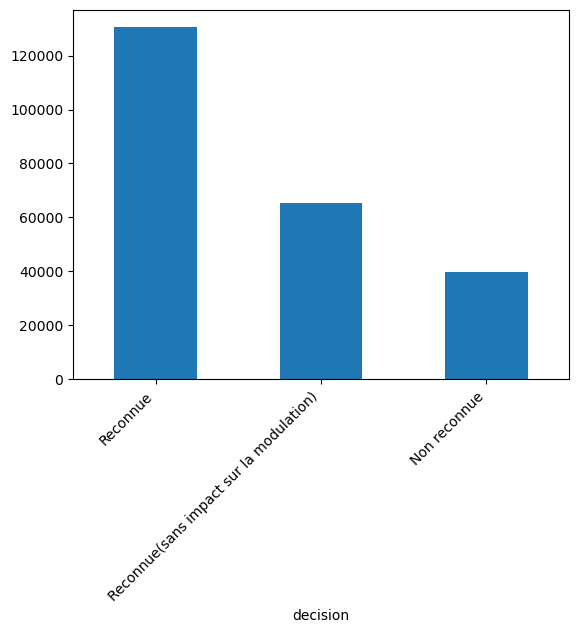

In [87]:
ax=df['decision'].value_counts().plot(kind='bar')

# Rotating the x-axis labels to 45 degrees and aligning them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Display the plot
plt.show()

## Decision time

In [88]:
## Compute recongnition time
df['decision_time']=(df['date_parution_jo']-df['debut_evenement'])/np.timedelta64(1, 'D')

In [89]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision,event_year,decision_time
43661,5063,LA GRAVE,2001-03-19,2001-03-25,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2001,257.0
43662,5128,SAINT ANDRE D EMBRUN,2001-03-29,2001-03-29,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2001,247.0
43663,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2000,373.0
43664,6031,CANTARON,2000-11-23,2000-11-24,2001-11-15,2001-12-01,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0100649A,Reconnue,2000,373.0
43665,6057,L'ESCARENE,2000-10-30,2000-10-31,2001-11-15,2001-12-01,Mouvement de Terrain,MVT,Simple,INTE0100649A,Reconnue,2000,397.0


In [90]:
import plotly.graph_objects as go

# Calculate the quantiles for each year
quantiles_per_year = df.groupby('event_year')['decision_time'].quantile([0.25, 0.5, 0.75]).unstack(level=1)
quantiles_per_year_sec = df[df['code_peril'] == 'SEC'].groupby('event_year')['decision_time'].quantile([0.25, 0.5, 0.75]).unstack(level=1)

# Create the figure
fig = go.Figure()

# Add lines for each quantile for all data
for quantile in [0.25, 0.5, 0.75]:
    fig.add_trace(go.Scatter(x=quantiles_per_year.index, y=quantiles_per_year[quantile],
                             mode='lines+markers', name=f'{quantile * 100}% Quantile (All)',
                             visible=True))

# Add lines for each quantile for SEC data
for quantile in [0.25, 0.5, 0.75]:
    fig.add_trace(go.Scatter(x=quantiles_per_year_sec.index, y=quantiles_per_year_sec[quantile],
                             mode='lines+markers', name=f'{quantile * 100}% Quantile (SEC)',
                             visible=False))

# Create year ranges for slider
years = list(range(df['event_year'].min(), df['event_year'].max() + 1))

# Update layout to include dropdown and slider
fig.update_layout(
    title='Quantiles of Decision Time per Event Year',
    xaxis_title='Event Year',
    yaxis_title='Decision Time',
    legend_title='Quantiles',
    updatemenus=[
        {
            'buttons': [
                {
                    'method': 'update',
                    'label': 'All',
                    'args': [{'visible': [True]*3 + [False]*3}]
                },
                {
                    'method': 'update',
                    'label': 'SEC',
                    'args': [{'visible': [False]*3 + [True]*3}]
                }
            ],
            'direction': 'down',
            'showactive': True
        }
    ],
    sliders=[{
        'steps': [{'method': 'update', 'label': str(year), 'args': [
            {'x': ([quantiles_per_year.index[quantiles_per_year.index >= year].tolist()] * 3) + ([quantiles_per_year_sec.index[quantiles_per_year_sec.index >= year].tolist()] * 3)}
        ]} for year in years],
        'currentvalue': {'prefix': 'Start Year: '}
    }]
)

# Show the plot
fig.show()

In [91]:
import plotly.graph_objects as go
import pandas as pd

# Filter data for decisions recognized (decision=='Reconnue') and SEC peril
recognized_sec_df = df[(df['decision'] == 'Reconnue') & (df['code_peril'] == 'SEC')]

# Filter data for all SEC decisions
all_sec_df = df[df['code_peril'] == 'SEC']

# Count recognized SEC decisions per year
counts_per_year_sec_recognized = recognized_sec_df.groupby('event_year')['decision'].count()

# Count all SEC decisions per year
counts_per_year_sec_all = all_sec_df.groupby('event_year')['decision'].count()

# Create a DataFrame to combine the counts
combined_df = pd.DataFrame({'Recognized SEC': counts_per_year_sec_recognized,
                            'All SEC': counts_per_year_sec_all})

# Create the figure
fig = go.Figure()

# Add lines for recognized and all SEC decisions
fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df['Recognized SEC'],
                           mode='lines+markers', name='Recognized SEC Decisions',
                           visible=True))

fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df['All SEC'],
                           mode='lines+markers', name='All SEC Decisions',
                           visible=True))

# Create year ranges for slider
years = list(range(combined_df.index.min(), combined_df.index.max() + 1))

fig.update_layout(
    title='Count of SEC Decisions Over Time',
    xaxis_title='Year',
    yaxis_title='Count of SEC Decisions',

    sliders=[{
        'steps': [{'method': 'update', 'label': str(year), 'args': [
            {'x': [combined_df.index[combined_df.index >= year].tolist()],
             'x': [combined_df.index[combined_df.index >= year].tolist()]}
        ]} for year in years],
        'currentvalue': {'prefix': 'Start Year: '}
    }]
)

fig.show()

In [92]:
df[(df['code_peril'] == 'SEC')]['decision'].describe()

count        73322
unique           3
top       Reconnue
freq         42753
Name: decision, dtype: object

In [93]:
# Filter the DataFrame
filtered_df = df[(df['event_year'] == 2020) & (df['code_peril'] == 'SEC')]

# Describe the 'decision_time' column
description = filtered_df['decision'].value_counts()

print(description)

decision
Non reconnue                               2749
Reconnue                                   2596
Reconnue(sans impact sur la modulation)      20
Name: count, dtype: int64


In [94]:
# Filter the DataFrame
filtered_df = df[(df['event_year'] == 2000) & (df['code_peril'] == 'SEC')]

# Describe the 'decision_time' column
description = filtered_df['decision_time'].describe()

print(description)


count      76.000000
mean     1298.368421
std       624.364762
min       504.000000
25%       909.000000
50%      1103.000000
75%      1654.000000
max      3035.000000
Name: decision_time, dtype: float64


In [95]:
df['decision_time'].describe()

count    235462.000000
mean        277.841669
std         437.329245
min           3.000000
25%           5.000000
50%         103.000000
75%         431.000000
max        7104.000000
Name: decision_time, dtype: float64

In [96]:
df['decision_time'].describe(percentiles=[0.99])

count    235462.000000
mean        277.841669
std         437.329245
min           3.000000
50%         103.000000
99%        2190.000000
max        7104.000000
Name: decision_time, dtype: float64

In [97]:
df.query("code_peril == 'ICB'")['decision_time'].describe(percentiles=[0.99])

count    112288.000000
mean         77.798046
std          91.804484
min           3.000000
50%          46.000000
99%         382.000000
max        2641.000000
Name: decision_time, dtype: float64

## Define study period

### Note

Recognizing disasters can sometimes take time, so let’s narrow our focus to events that occurred before 2023. It’s worth noting that 99% of flood disasters are recognized within a year. To account for factors like infrastructure development, we may want to concentrate on the most recent decades.

In [98]:
min_year_event =  2003
max_year_event = 2022

In [99]:
df = df[(df['debut_evenement'].dt.year >= min_year_event) & (df['debut_evenement'].dt.year <= max_year_event)]

In [100]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision,event_year,decision_time
54086,2106,BOURG ET COMIN,2003-08-17,2003-08-18,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,297.0
54087,7146,LYAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0
54088,7310,SAVAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0
54089,7333,VANOSC,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0
54090,11145,FLEURY,2003-12-03,2003-12-04,2004-05-21,2004-06-09,Chocs Mécaniques liés à l'action des Vagues,CMV,Simple,INTE0400285A,Reconnue,2003,189.0


## Types of desasters

In [101]:
codification = df[['nom_peril', 'code_peril']].drop_duplicates(inplace=False)
codification

,nom_peril,code_peril
54086,Inondations et/ou Coulées de Boue,ICB
54090,Chocs Mécaniques liés à l'action des Vagues,CMV
54145,Mouvement de Terrain,MVT
169933,Secousse Sismique,SEI
171045,Inondations Remontée Nappe,IRN
172467,Avalanche,AVA
175233,Sécheresse,SEC
179638,Raz de Marée,RAZ
185008,Lave Torrentielle,LVT
187517,Vents Cycloniques,VCY


In [102]:
df['nom_peril'].value_counts()

nom_peril
Sécheresse                                     60550
Inondations et/ou Coulées de Boue              40620
Chocs Mécaniques liés à l'action des Vagues     3851
Mouvement de Terrain                            3648
Secousse Sismique                               1355
Inondations Remontée Nappe                       727
Vents Cycloniques                                586
Avalanche                                         43
Grêle                                             26
Poids de la Neige                                 12
Lave Torrentielle                                  4
Algues Sargasses                                   3
Raz de Marée                                       2
Eruption Volcanique                                1
Name: count, dtype: int64

<Axes: xlabel='nom_peril'>

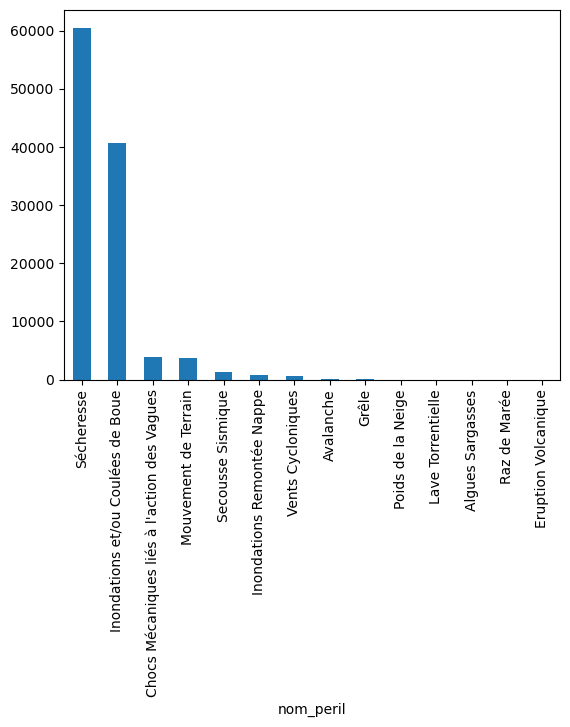

In [103]:
df['nom_peril'].value_counts().plot(kind='bar')

## Count the number of disasters per type for each year

<Axes: xlabel='nom_peril'>

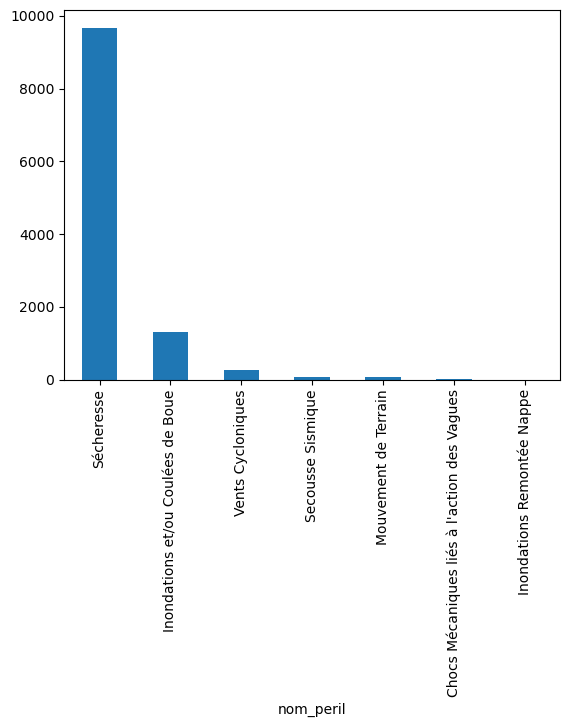

In [104]:
df[df['event_year']==2022]['nom_peril'].value_counts().plot(kind='bar')

<Axes: xlabel='nom_peril'>

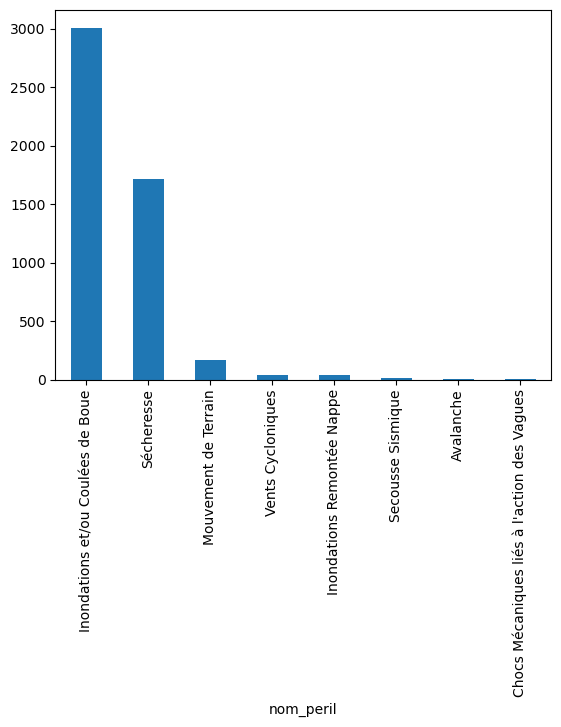

In [105]:
df[df['event_year']==2021]['nom_peril'].value_counts().plot(kind='bar')

<Axes: xlabel='nom_peril'>

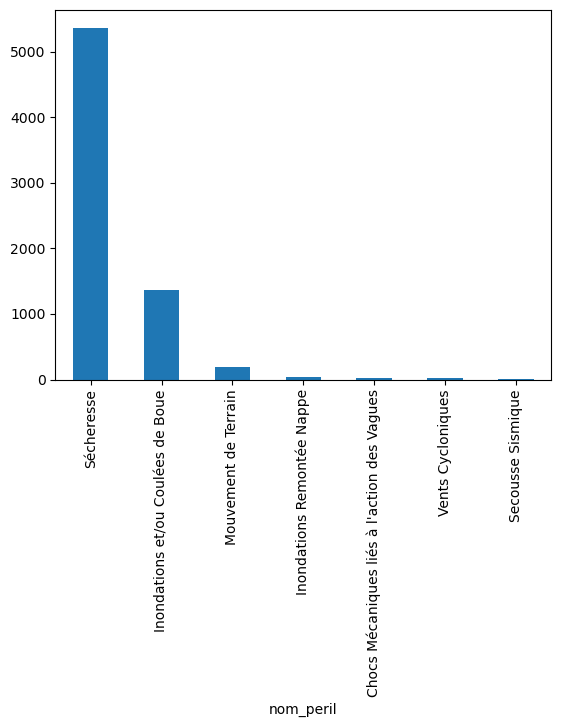

In [106]:
df[df['event_year']==2020]['nom_peril'].value_counts().plot(kind='bar')

In [107]:
# Group by year and item, summing up sales
yearly_disasters = df.groupby(['event_year', 'code_peril']).size().reset_index(name='Count')
yearly_disasters.head()


,event_year,code_peril,Count
0,2003,AVA,1
1,2003,CMV,26
2,2003,ICB,2457
3,2003,IRN,5
4,2003,MVT,34


In [108]:
# Create a line plot using Plotly
fig = px.line(yearly_disasters, x='event_year', y='Count', color='code_peril', markers=True,
              title='Disaster count for per type for each year')
fig.update_xaxes(title_text='Year')
fig.update_yaxes(title_text='Count')
fig.show()

### Note

In 1999, France experienced a notable peak in storm-related disasters. Over the past few decades, floods and droughts have emerged as the predominant disaster types, with droughts showing an upward trend.

We might want to consider asking experts if disaster categories have been merged, renamed, or suppressed.

## Event duration

In [109]:
df.columns

Index(['insee', 'nom_commune', 'debut_evenement', 'fin_evenement',
       'date_arrete', 'date_parution_jo', 'nom_peril', 'code_peril',
       'franchise', 'code_nor', 'decision', 'event_year', 'decision_time'],
      dtype='object')

In [110]:
# create event duration column
df['event_duration']=(df['fin_evenement']-df['debut_evenement'])/np.timedelta64(1, 'D')

In [111]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision,event_year,decision_time,event_duration
54086,2106,BOURG ET COMIN,2003-08-17,2003-08-18,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,297.0,1.0
54087,7146,LYAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54088,7310,SAVAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54089,7333,VANOSC,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54090,11145,FLEURY,2003-12-03,2003-12-04,2004-05-21,2004-06-09,Chocs Mécaniques liés à l'action des Vagues,CMV,Simple,INTE0400285A,Reconnue,2003,189.0,1.0


In [112]:
df['event_duration'].describe()

count    111428.000000
mean         97.652017
std         119.641989
min           0.000000
25%           1.000000
50%          90.000000
75%         152.000000
max        1095.000000
Name: event_duration, dtype: float64

<Axes: xlabel='event_duration'>

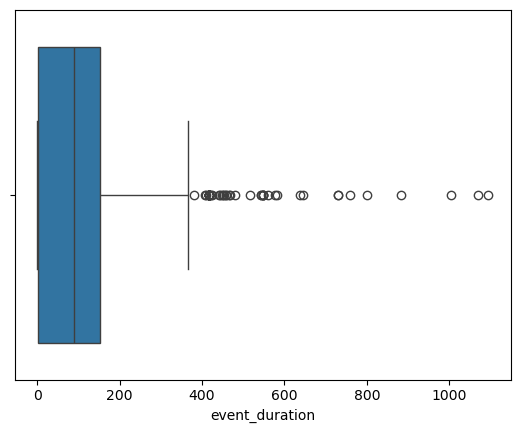

In [113]:
sns.boxplot(x=df["event_duration"])

In [114]:
df["event_duration"].describe(percentiles=[0.99])

count    111428.000000
mean         97.652017
std         119.641989
min           0.000000
50%          90.000000
99%         365.000000
max        1095.000000
Name: event_duration, dtype: float64

In [115]:
df[df['code_peril']=='ICB']["event_duration"].describe()

count    40620.000000
mean         1.757090
std          3.358094
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max        151.000000
Name: event_duration, dtype: float64

In [116]:
df[df['code_peril']=='ICB']["event_duration"].describe(percentiles=[0.99])

count    40620.000000
mean         1.757090
std          3.358094
min          0.000000
50%          1.000000
99%         21.000000
max        151.000000
Name: event_duration, dtype: float64

In [117]:
df[(df['code_peril']=='ICB') & (df['event_year']==2022)]["event_duration"].describe(percentiles=[0.99])

count    1300.000000
mean        1.510000
std         2.436392
min         0.000000
50%         1.000000
99%        22.000000
max        22.000000
Name: event_duration, dtype: float64

In [118]:
df[(df['code_peril']=='ICB') & (df['event_year']==2020)]["event_duration"].describe(percentiles=[0.99])

count    1358.000000
mean        1.486009
std         3.570042
min         0.000000
50%         1.000000
99%         7.000000
max        91.000000
Name: event_duration, dtype: float64

In [119]:
df[(df['code_peril']=='ICB') & (df['event_year']==1990)]["event_duration"].describe(percentiles=[0.99])

count    0.0
mean     NaN
std      NaN
min      NaN
50%      NaN
99%      NaN
max      NaN
Name: event_duration, dtype: float64

In [120]:
df.columns

Index(['insee', 'nom_commune', 'debut_evenement', 'fin_evenement',
       'date_arrete', 'date_parution_jo', 'nom_peril', 'code_peril',
       'franchise', 'code_nor', 'decision', 'event_year', 'decision_time',
       'event_duration'],
      dtype='object')

In [121]:
# Group by year and item, summing up sales
yearly_durations_per_disasters = df.groupby(['event_year', 'code_peril']).size().reset_index(name='Count')
yearly_disasters.head()

,event_year,code_peril,Count
0,2003,AVA,1
1,2003,CMV,26
2,2003,ICB,2457
3,2003,IRN,5
4,2003,MVT,34


In [122]:
# Group by Year and Disaster, then get the max and median Duration
yearly_durations_per_disasters = df.groupby(['event_year', 'code_peril'])['event_duration'].agg(['max', 'mean', 'median']).reset_index()
yearly_durations_per_disasters.head()

,event_year,code_peril,max,mean,median
0,2003,AVA,0.0,0.000000,0.0
1,2003,CMV,2.0,0.961538,1.0
2,2003,ICB,6.0,1.347171,1.0
3,2003,IRN,89.0,31.200000,2.0
4,2003,MVT,638.0,38.176471,1.0


In [123]:
# Plotting with Plotly
fig = px.line(yearly_durations_per_disasters, x='event_year', y='max', color='code_peril', markers=True, title='Longest Duration of Natural Disasters per Year')
fig.update_layout(xaxis_title='event_year', yaxis_title='event_duration (days)', legend_title='code_peril')
fig.show()

fig = px.line(yearly_durations_per_disasters, x='event_year', y='mean', color='code_peril', markers=True, title='Mean Duration of Natural Disasters per Year')
fig.update_layout(xaxis_title='event_year', yaxis_title='event_duration (days)', legend_title='code_peril')
fig.show()

fig = px.line(yearly_durations_per_disasters, x='event_year', y='median', color='code_peril', markers=True, title='Median Duration of Natural Disasters per Year')
fig.update_layout(xaxis_title='event_year', yaxis_title='event_duration (days)', legend_title='code_peril')
fig.show()


In [124]:
codification

,nom_peril,code_peril
54086,Inondations et/ou Coulées de Boue,ICB
54090,Chocs Mécaniques liés à l'action des Vagues,CMV
54145,Mouvement de Terrain,MVT
169933,Secousse Sismique,SEI
171045,Inondations Remontée Nappe,IRN
172467,Avalanche,AVA
175233,Sécheresse,SEC
179638,Raz de Marée,RAZ
185008,Lave Torrentielle,LVT
187517,Vents Cycloniques,VCY


### Note

- Drought is by far the natural disaster with the longest median and average durations over the past two decades.
- In terms of maximum duration, landslides and drought are predominant over the same period.

In [125]:
## Department with most drough

In [126]:
df.columns

Index(['insee', 'nom_commune', 'debut_evenement', 'fin_evenement',
       'date_arrete', 'date_parution_jo', 'nom_peril', 'code_peril',
       'franchise', 'code_nor', 'decision', 'event_year', 'decision_time',
       'event_duration'],
      dtype='object')

In [127]:
# get and display latitude and longitude first before saving

In [128]:
# save to parquet
#combined_df.to_parquet(os.path.join(processed_data_folder_name, decrees_filename_clean))

In [129]:
df.head()

,insee,nom_commune,debut_evenement,fin_evenement,date_arrete,date_parution_jo,nom_peril,code_peril,franchise,code_nor,decision,event_year,decision_time,event_duration
54086,2106,BOURG ET COMIN,2003-08-17,2003-08-18,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,297.0,1.0
54087,7146,LYAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54088,7310,SAVAS,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54089,7333,VANOSC,2003-12-01,2003-12-02,2004-05-21,2004-06-09,Inondations et/ou Coulées de Boue,ICB,Simple,INTE0400285A,Reconnue,2003,191.0,1.0
54090,11145,FLEURY,2003-12-03,2003-12-04,2004-05-21,2004-06-09,Chocs Mécaniques liés à l'action des Vagues,CMV,Simple,INTE0400285A,Reconnue,2003,189.0,1.0


In [130]:
'''
import pandas as pd

# Group by 'event_year', 'nom_commune', and 'cod_peril' and count the number of disasters
disaster_counts = df[['nom_commune', 'code_peril', 'event_year']].groupby(['event_year', 'nom_commune', 'code_peril']).size().reset_index(name='number_of_disasters')

# Sort by 'event_year' in ascending order and 'number_of_disasters' in descending order
disaster_counts = disaster_counts.sort_values(by=['event_year', 'number_of_disasters'], ascending=[False, False])

# Print the resulting DataFrame
print(disaster_counts['event_year='])

filtered_df = df[(df['col1'] == 'val1') & (df['col2'] == 'val2')]
'''

"\nimport pandas as pd\n\n# Group by 'event_year', 'nom_commune', and 'cod_peril' and count the number of disasters\ndisaster_counts = df[['nom_commune', 'code_peril', 'event_year']].groupby(['event_year', 'nom_commune', 'code_peril']).size().reset_index(name='number_of_disasters')\n\n# Sort by 'event_year' in ascending order and 'number_of_disasters' in descending order\ndisaster_counts = disaster_counts.sort_values(by=['event_year', 'number_of_disasters'], ascending=[False, False])\n\n# Print the resulting DataFrame\nprint(disaster_counts['event_year='])\n\nfiltered_df = df[(df['col1'] == 'val1') & (df['col2'] == 'val2')]\n"